# ============================================================
# MID PROJECT: Cardiovascular Disease Analysis
# Dataset: cardio_train.csv (70,000 records)
# Author: [Your Name]
# ============================================================

"""
RESEARCH QUESTIONS:
-------------------
Q1. Does age increase the risk of cardiovascular disease?

Q2. Is there a significant difference in BMI between patients
    with and without heart disease?

Q3. How do blood pressure levels relate to cardiovascular disease?

Q4. Does gender affect the likelihood of cardiovascular disease?

Q5. Which lifestyle factors (smoking, alcohol, activity)
    correlate most with heart disease?
    
Q6. Does cholesterol/glucose level impact disease presence?
"""

In [2]:
# Direct download - no API key needed
!pip install kagglehub -q
import kagglehub, glob, shutil

path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")
print("Downloaded to:", path)

csv_files = glob.glob(path + '/**/*.csv', recursive=True)
print("Files:", csv_files)

shutil.copy(csv_files[0], 'cardio_train.csv')
print("✅ Ready!")
# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

# --- Read Dataset ---
df = pd.read_csv('cardio_train.csv', sep=';')

print("✅ Dataset Loaded!")
print(f"   Shape : {df.shape}")
print(f"   Rows  : {df.shape[0]:,}")
print(f"   Cols  : {df.shape[1]}")
df.head()

Using Colab cache for faster access to the 'cardiovascular-disease-dataset' dataset.
Downloaded to: /kaggle/input/cardiovascular-disease-dataset
Files: ['/kaggle/input/cardiovascular-disease-dataset/cardio_train.csv']
✅ Ready!
✅ Dataset Loaded!
   Shape : (70000, 13)
   Rows  : 70,000
   Cols  : 13


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# --- Basic Info ---
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [4]:
# --- Statistical Summary ---
df.describe().round(2)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0


In [5]:
# --- Missing Values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
id,0,0.0
age,0,0.0
gender,0,0.0
height,0,0.0
weight,0,0.0
ap_hi,0,0.0
ap_lo,0,0.0
cholesterol,0,0.0
gluc,0,0.0
smoke,0,0.0


In [6]:
# --- Duplicates & Quality Issues ---
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nNegative ap_hi  : {(df['ap_hi'] < 0).sum()}")
print(f"Negative ap_lo  : {(df['ap_lo'] < 0).sum()}")
print(f"ap_hi > 250     : {(df['ap_hi'] > 250).sum()}")
print(f"Height < 100cm  : {(df['height'] < 100).sum()}")
print(f"Weight < 20kg   : {(df['weight'] < 20).sum()}")
print(f"Age range(years): {df['age'].min()//365} – {df['age'].max()//365}")

Duplicate rows: 0

Negative ap_hi  : 7
Negative ap_lo  : 1
ap_hi > 250     : 40
Height < 100cm  : 29
Weight < 20kg   : 2
Age range(years): 29 – 64


In [7]:
# DATA CLEANING
df_clean = df.copy()

# 1. Remove duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"1. Duplicates removed        : {before - len(df_clean)}")

# 2. Convert age days → years
df_clean['age'] = df_clean['age'] // 365
print(f"2. Age converted to years ✅")

# 3. Remove BP outliers
before = len(df_clean)
df_clean = df_clean[
    (df_clean['ap_hi'] >= 60)  & (df_clean['ap_hi'] <= 250) &
    (df_clean['ap_lo'] >= 40)  & (df_clean['ap_lo'] <= 200) &
    (df_clean['ap_hi'] > df_clean['ap_lo'])
]
print(f"3. BP outliers removed       : {before - len(df_clean)}")

# 4. Remove height/weight outliers
before = len(df_clean)
df_clean = df_clean[
    (df_clean['height'] >= 100) & (df_clean['height'] <= 220) &
    (df_clean['weight'] >= 20)  & (df_clean['weight'] <= 200)
]
print(f"4. Height/Weight outliers    : {before - len(df_clean)}")

# 5. Add BMI
df_clean['BMI'] = (df_clean['weight'] /
                   (df_clean['height'] / 100) ** 2).round(2)
print(f"5. BMI column added ✅")

# 6. BMI Category
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else:          return 'Obese'

df_clean['BMI_Category']  = df_clean['BMI'].apply(bmi_category)
df_clean['gender_label']  = df_clean['gender'].map({1:'Female', 2:'Male'})
df_clean['cardio_label']  = df_clean['cardio'].map({0:'No Disease', 1:'Has Disease'})
print(f"6. BMI_Category, gender_label, cardio_label added ✅")
print(f"\n✅ Final shape: {df_clean.shape}")
df_clean.head()

1. Duplicates removed        : 0
2. Age converted to years ✅
3. BP outliers removed       : 1328
4. Height/Weight outliers    : 28
5. BMI column added ✅
6. BMI_Category, gender_label, cardio_label added ✅

✅ Final shape: (68644, 17)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,BMI_Category,gender_label,cardio_label
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.97,Normal,Male,No Disease
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.93,Obese,Female,Has Disease
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.51,Normal,Female,Has Disease
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.71,Overweight,Male,Has Disease
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.01,Normal,Female,No Disease


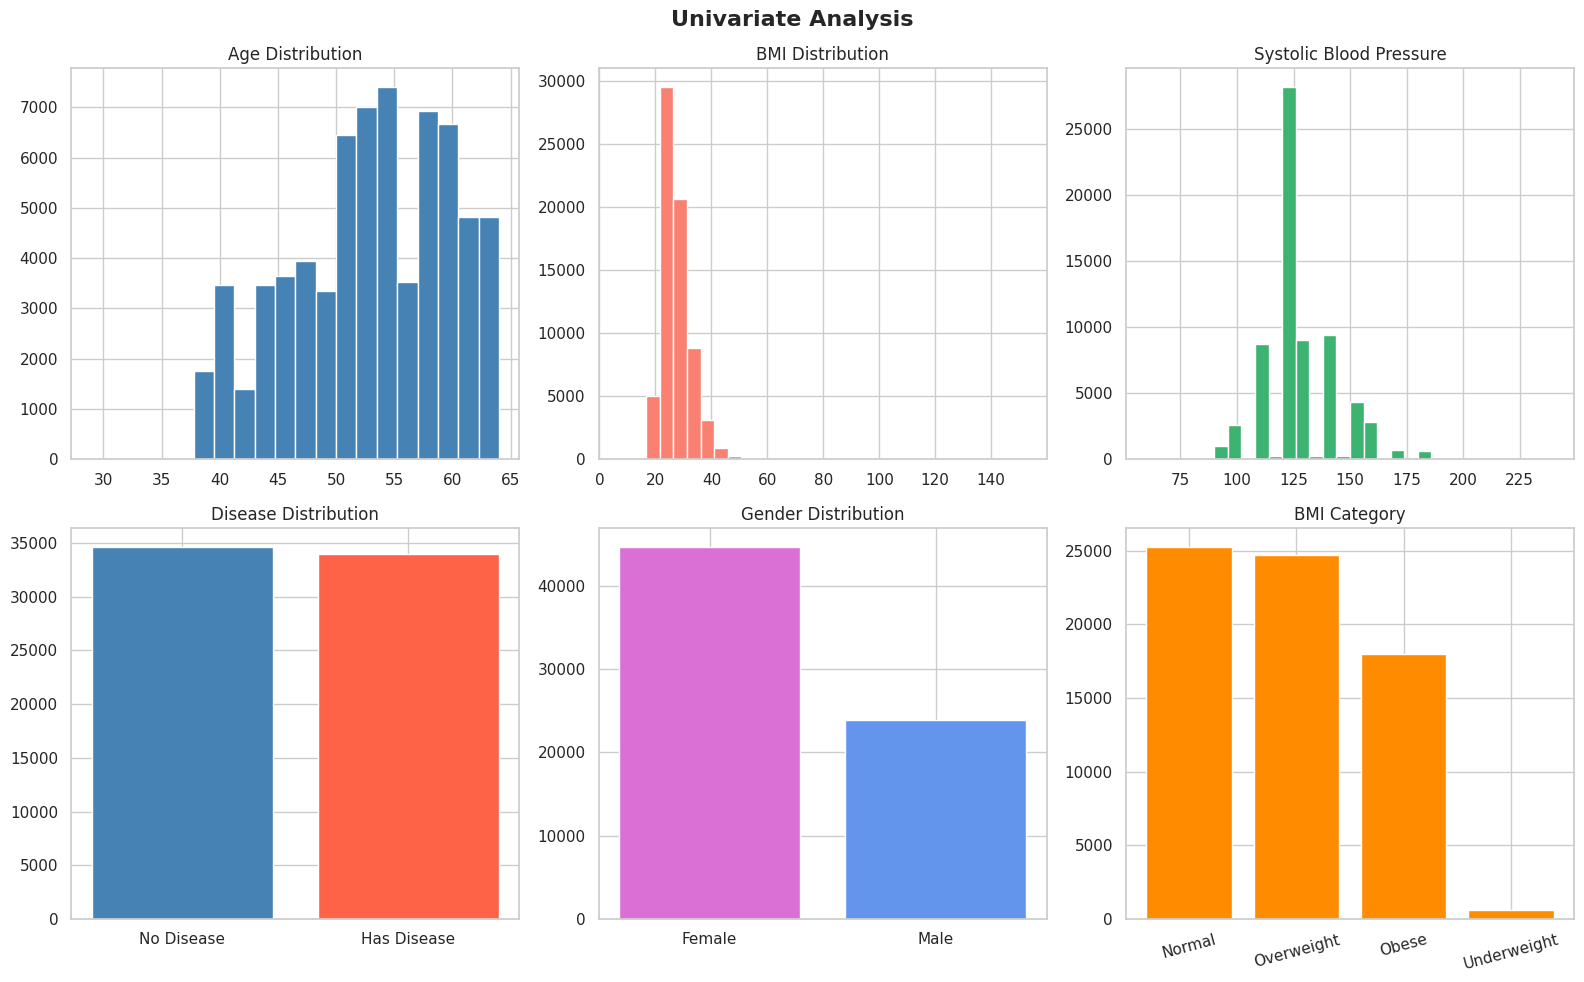

✅ Plot 1: Univariate Analysis


In [8]:
# UNIVARIATE ANALYSIS
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style='whitegrid', palette='Set2')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Univariate Analysis', fontsize=16, fontweight='bold')

axes[0,0].hist(df_clean['age'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')

axes[0,1].hist(df_clean['BMI'], bins=30, color='salmon', edgecolor='white')
axes[0,1].set_title('BMI Distribution')

axes[0,2].hist(df_clean['ap_hi'], bins=30, color='mediumseagreen', edgecolor='white')
axes[0,2].set_title('Systolic Blood Pressure')

cardio_counts = df_clean['cardio_label'].value_counts()
axes[1,0].bar(cardio_counts.index, cardio_counts.values,
              color=['steelblue','tomato'], edgecolor='white')
axes[1,0].set_title('Disease Distribution')

gender_counts = df_clean['gender_label'].value_counts()
axes[1,1].bar(gender_counts.index, gender_counts.values,
              color=['orchid','cornflowerblue'], edgecolor='white')
axes[1,1].set_title('Gender Distribution')

bmi_counts = df_clean['BMI_Category'].value_counts()
axes[1,2].bar(bmi_counts.index, bmi_counts.values,
              color='darkorange', edgecolor='white')
axes[1,2].set_title('BMI Category')
axes[1,2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print("✅ Plot 1: Univariate Analysis")

/tmp/ipykernel_1099/3995326886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cardio_label', y='age',


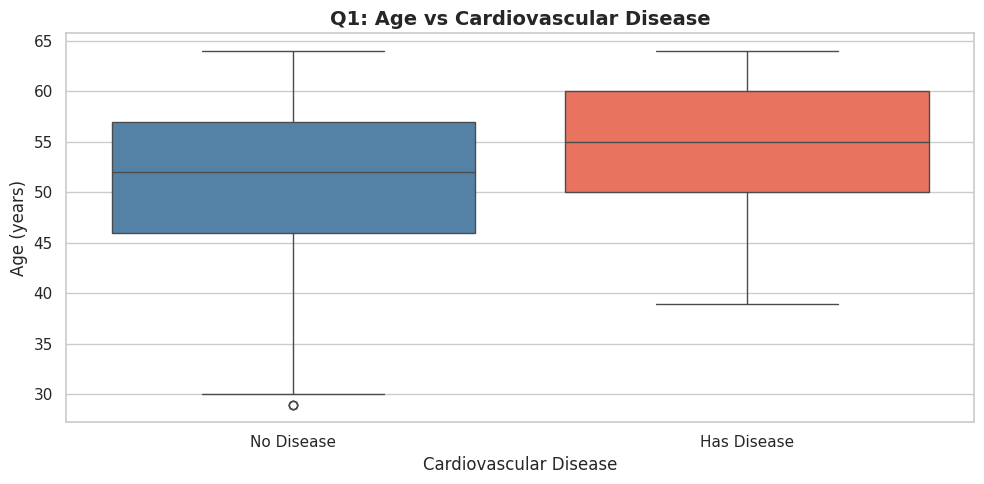

✅ Plot 2: Boxplot


In [9]:
# PLOT 2: Age vs Disease - Boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean, x='cardio_label', y='age',
            palette=['steelblue','tomato'])
plt.title('Q1: Age vs Cardiovascular Disease', fontsize=14, fontweight='bold')
plt.xlabel('Cardiovascular Disease')
plt.ylabel('Age (years)')
plt.tight_layout()
plt.show()
print("✅ Plot 2: Boxplot")

/tmp/ipykernel_1099/2265866236.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='cardio_label', y='BMI',


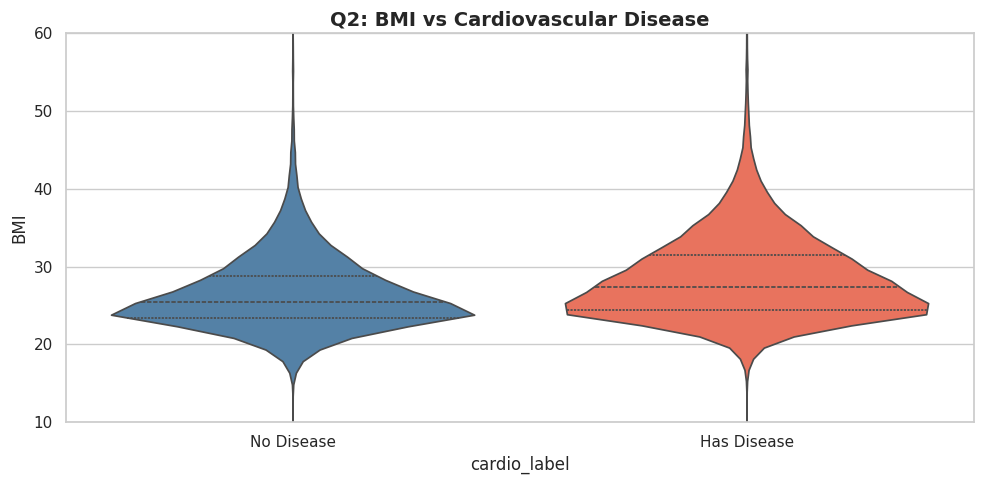

✅ Plot 3: Violin Plot


In [10]:
# PLOT 3: BMI vs Disease - Violin
plt.figure(figsize=(10,5))
sns.violinplot(data=df_clean, x='cardio_label', y='BMI',
               palette=['steelblue','tomato'], inner='quartile')
plt.title('Q2: BMI vs Cardiovascular Disease', fontsize=14, fontweight='bold')
plt.ylim(10, 60)
plt.tight_layout()
plt.show()
print("✅ Plot 3: Violin Plot")

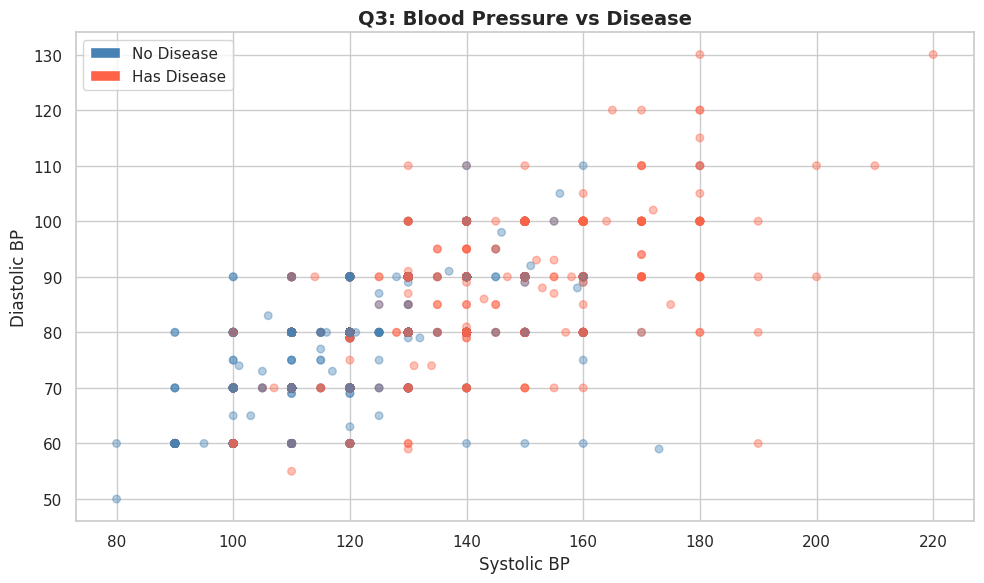

✅ Plot 4: Scatter Plot


In [11]:
# PLOT 4: Blood Pressure - Scatter
sample = df_clean.sample(3000, random_state=42)
plt.figure(figsize=(10,6))
colors = sample['cardio'].map({0:'steelblue', 1:'tomato'})
plt.scatter(sample['ap_hi'], sample['ap_lo'],
            c=colors, alpha=0.4, s=30)
from matplotlib.patches import Patch
plt.legend(handles=[Patch(facecolor='steelblue', label='No Disease'),
                    Patch(facecolor='tomato',     label='Has Disease')])
plt.title('Q3: Blood Pressure vs Disease', fontsize=14, fontweight='bold')
plt.xlabel('Systolic BP'); plt.ylabel('Diastolic BP')
plt.tight_layout()
plt.show()
print("✅ Plot 4: Scatter Plot")

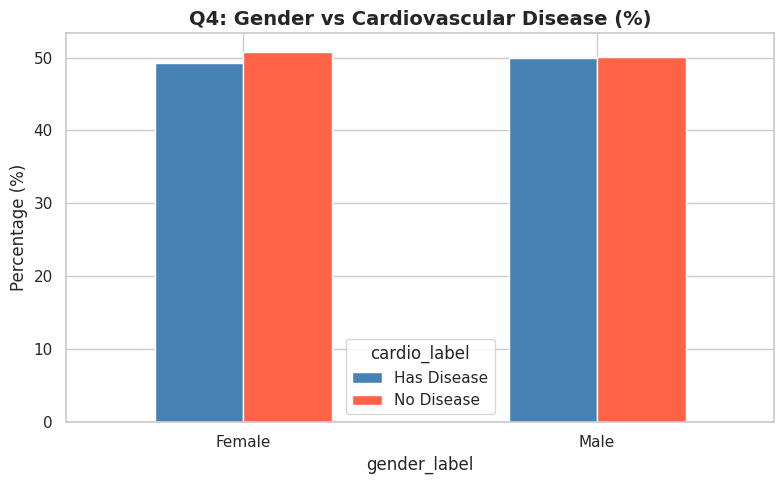

✅ Plot 5: Grouped Bar Chart


In [12]:
# PLOT 5: Gender vs Disease - Grouped Bar
gender_cardio = df_clean.groupby(
    ['gender_label','cardio_label']).size().unstack()
gender_pct = gender_cardio.div(gender_cardio.sum(axis=1), axis=0) * 100
gender_pct.plot(kind='bar', figsize=(8,5),
                color=['steelblue','tomato'], edgecolor='white', rot=0)
plt.title('Q4: Gender vs Cardiovascular Disease (%)',
          fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()
print("✅ Plot 5: Grouped Bar Chart")

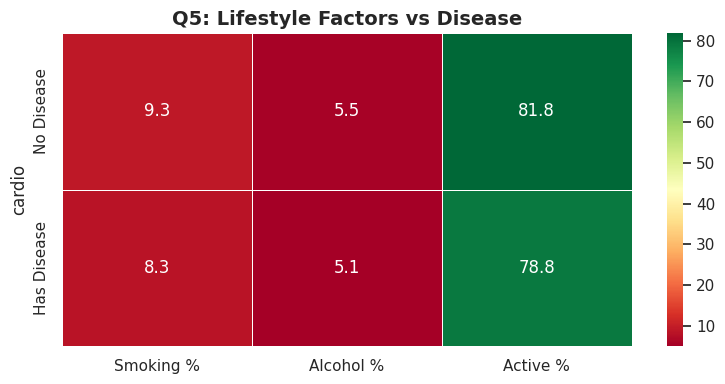

✅ Plot 6: Heatmap


In [13]:
# PLOT 6: Lifestyle Heatmap
lifestyle = df_clean.groupby('cardio')[['smoke','alco','active']].mean()*100
plt.figure(figsize=(8,4))
sns.heatmap(lifestyle, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=['Smoking %','Alcohol %','Active %'],
            yticklabels=['No Disease','Has Disease'], linewidths=0.5)
plt.title('Q5: Lifestyle Factors vs Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Plot 6: Heatmap")

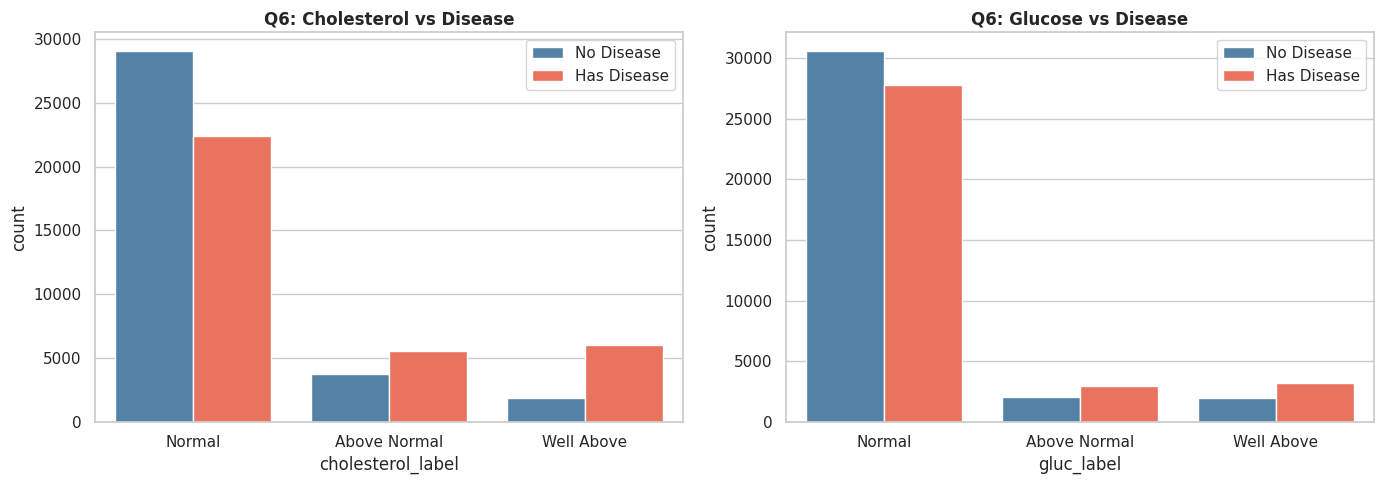

✅ Plot 7: Countplot


In [14]:
# PLOT 7: Cholesterol & Glucose - Countplot
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df_plot = df_clean.copy()
df_plot['cholesterol_label'] = df_plot['cholesterol'].map(
    {1:'Normal', 2:'Above Normal', 3:'Well Above'})
df_plot['gluc_label'] = df_plot['gluc'].map(
    {1:'Normal', 2:'Above Normal', 3:'Well Above'})

sns.countplot(data=df_plot, x='cholesterol_label', hue='cardio_label',
              palette=['steelblue','tomato'], ax=axes[0],
              order=['Normal','Above Normal','Well Above'])
axes[0].set_title('Q6: Cholesterol vs Disease', fontweight='bold')
axes[0].legend(title='')

sns.countplot(data=df_plot, x='gluc_label', hue='cardio_label',
              palette=['steelblue','tomato'], ax=axes[1],
              order=['Normal','Above Normal','Well Above'])
axes[1].set_title('Q6: Glucose vs Disease', fontweight='bold')
axes[1].legend(title='')

plt.tight_layout()
plt.show()
print("✅ Plot 7: Countplot")

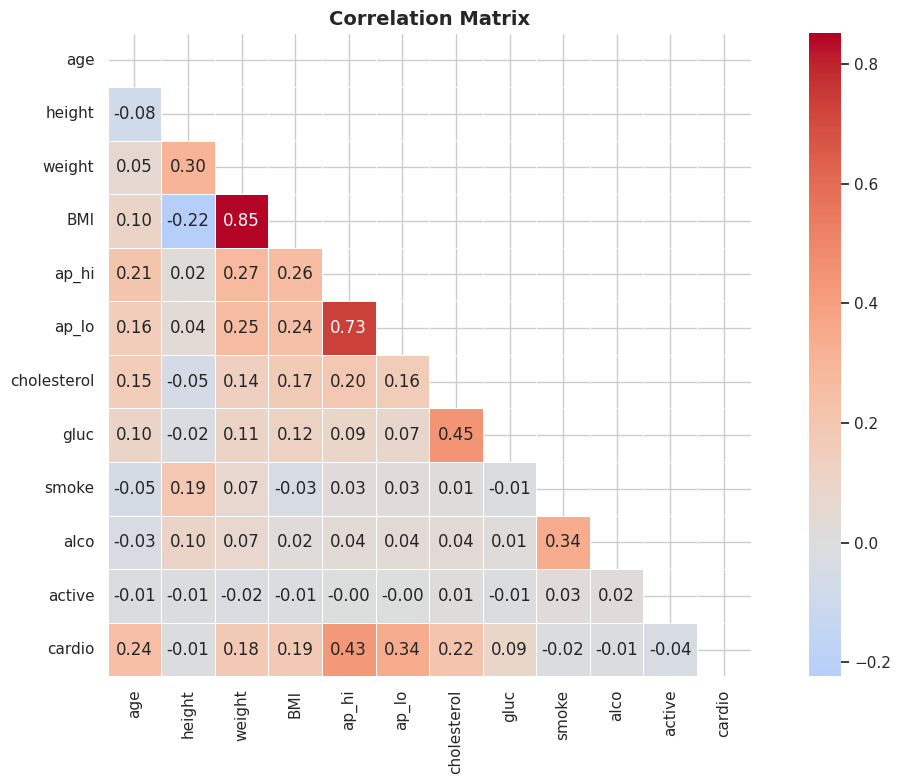

✅ Plot 8: Correlation Matrix


In [15]:
# PLOT 8: Correlation Heatmap
numeric_cols = ['age','height','weight','BMI','ap_hi','ap_lo',
                'cholesterol','gluc','smoke','alco','active','cardio']
plt.figure(figsize=(12,8))
corr = df_clean[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Plot 8: Correlation Matrix")

In [16]:
# CONCLUSIONS
print("=" * 55)
print("         PROJECT CONCLUSIONS")
print("=" * 55)

metrics = {
    'Age (years)'     : ('age',   'Q1 → Older patients at higher risk'),
    'BMI'             : ('BMI',   'Q2 → Higher BMI linked to disease'),
    'Systolic BP'     : ('ap_hi', 'Q3 → Higher BP = higher risk'),
}
for label, (col, insight) in metrics.items():
    d  = df_clean[df_clean['cardio']==1][col].mean()
    nd = df_clean[df_clean['cardio']==0][col].mean()
    print(f"\n{label}:")
    print(f"   With disease    : {d:.2f}")
    print(f"   Without disease : {nd:.2f}")
    print(f"   → {insight} ✅")

gender_risk = df_clean.groupby('gender_label')['cardio'].mean()*100
print(f"\nQ4 — Gender disease rate:")
for g, r in gender_risk.items(): print(f"   {g}: {r:.1f}%")

chol_risk = df_clean.groupby('cholesterol')['cardio'].mean()*100
print(f"\nQ6 — Cholesterol disease rate:")
for lvl, r in zip(['Normal','Above Normal','Well Above'], chol_risk):
    print(f"   {lvl}: {r:.1f}%")

print("\n" + "=" * 55)
print("✅ All 6 research questions answered!")
print("=" * 55)

         PROJECT CONCLUSIONS

Age (years):
   With disease    : 54.47
   Without disease : 51.23
   → Q1 → Older patients at higher risk ✅

BMI:
   With disease    : 28.48
   Without disease : 26.49
   → Q2 → Higher BMI linked to disease ✅

Systolic BP:
   With disease    : 133.90
   Without disease : 119.60
   → Q3 → Higher BP = higher risk ✅

Q4 — Gender disease rate:
   Female: 49.2%
   Male: 50.0%

Q6 — Cholesterol disease rate:
   Normal: 43.5%
   Above Normal: 59.6%
   Well Above: 76.3%

✅ All 6 research questions answered!
